![EncabezadoIN.JPG](attachment:EncabezadoIN.JPG)

# Tarea de agrupación

El objetivo de este notebook es mostrar cómo resolver una tarea de **agrupación (clustering)** utilizando la librería **scikit-learn**.

En este laboratorio aplicamos algoritmos de agrupación no supervisada al caso de *SenecaféAlpes*, una empresa dedicada a la producción de café de alta calidad. Usando un conjunto de datos con atributos de los granos de café, el objetivo es identificar patrones que apoyen los procesos de **control de calidad** y **optimización de mercado**. Siguiendo la metodología **CRISP-ML**, el proyecto incluye una sección de **preparación de datos**, modelamiento con **K-Means**, **DBSCAN** y **Gaussian Mixture Models**, además de validación cuantitativa y cualitativa. Finalmente, se presentan conclusiones y recomendaciones orientadas al negocio, útiles para la organización.



# 1 Caso
SenecaféAlpes es una compañía dedicada a la producción, procesamiento y comercialización de café de alta calidad. Uno de sus principales retos consiste en garantizar la uniformidad y trazabilidad de sus granos, ya que la heterogeneidad en tamaño, forma y estructura puede afectar tanto los procesos de tostión como la percepción de calidad del consumidor final. Para enfrentar este desafío, la empresa implementó un sistema de visión por computadora que capturó imágenes de granos correspondientes a siete variedades registradas de café. Tras un proceso de segmentación y extracción de características, se construyó un conjunto de datos con 16 atributos para cada grano.

A partir de este insumo, SenecaféAlpes ha decidido emprender un proyecto de analítica de datos cuyo objetivo es la aplicación de técnicas de agrupación para identificar patrones morfológicos que permitan caracterizar las distintas variedades de café. La expectativa de la empresa es que los resultados de este estudio generen beneficios en tres dimensiones principales: (i) control de calidad, mediante la caracterización morfológica de los granos para estandarizar procesos de selección y clasificación; (ii) optimización del mercado, a partir de la comprensión de las agrupaciones naturales de las variedades y su aprovechamiento en el diseño de nuevas mezclas con valor agregado; (iii) innovación en trazabilidad, estableciendo las bases para sistemas automáticos de identificación que reduzcan la dependencia de evaluaciones manuales.
Para llevar a cabo este proyecto, la empresa nos ha contratado como científicos de datos, proporcionándonos no solo el conjunto de datos generado, sino también la documentación correspondiente a la descripción detallada de cada atributo (diccionario).

- [Datos de entrenamiento](Datos_SenecaféAlpes.csv)
- [Diccionario de datos](Diccionario_SenecaféAlpes.xlsx)


## 1.1. Carga de librerías necesarias para implementación

In [2]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  # for plot styling

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, silhouette_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import NearestNeighbors

from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D # for 3D plots
%pip install yellowbrick

## 1.2 Cargar los datos

In [4]:
# Se cargan los datos.
df=pd.read_csv('data/Datos_SenecaféAlpes.csv', sep=';', encoding = "UTF-8")

# 2. Entendimiento de los datos

## 2.1. Perfilamiento de datos

In [5]:
df.shape

(14291, 19)

In [6]:
df.head()

,ID,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,RelacionAspecto,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4,DefectoVisible,MétodoSecado
0,G006149,50836,923618.0,358.515147,181.388899,alargado,NaN,NaN,254.413847,0.804762,0.983840,0.748853,0.709632,0.007052,0.001103,0.503578,0.995321,Normal,Lavado
1,G007234,62764,1003767.0,409.207082,198.330199,Alargado,NaN,64158.0,282.689948,0.703995,0.978272,0.782807,0.690824,0.006520,0.000916,0.477237,0.984666,NaN,Natural
2,G007054,59965,994266.0,389.088529,197.967275,Alargado,0.860886,60910.0,276.314692,0.661581,0.984485,0.762259,0.710159,0.006489,0.001018,0.504326,0.991211,Normal,Natural
3,G006619,55035,917.6,379.346822,185.390577,Alargado,0.872446,55591.0,NaN,0.799695,0.989998,0.821376,0.697811,0.006893,0.001008,0.486941,0.996380,Normal,Lavado
4,G013353,39324,737773.0,262.520242,191.176858,Alargado,0.685326,39758.0,223.760747,0.775392,0.989084,0.907867,0.852356,0.006676,0.002174,0.726511,0.997630,Normal,Lavado


In [7]:
# Revisar las características de los datos: completitud y tipo de dato
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14291 entries, 0 to 14290
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   14291 non-null  object 
 1   Area                 14291 non-null  int64  
 2   Perimetro            13054 non-null  float64
 3   LongitudEjeMayor     13890 non-null  float64
 4   LongitudEjeMenor     14291 non-null  float64
 5   RelacionAspecto      13825 non-null  object 
 6   Excentricidad        13687 non-null  float64
 7   AreaConvexa          12868 non-null  float64
 8   DiametroEquivalente  12368 non-null  float64
 9   Medida               14291 non-null  float64
 10  Solidez              11985 non-null  float64
 11  Redondez             12228 non-null  float64
 12  Compacidad           13641 non-null  float64
 13  FactorForma1         13172 non-null  float64
 14  FactorForma2         13185 non-null  float64
 15  FactorForma3         13813 non-null 

In [8]:
# Resumen de los estadisticos de las variables numéricas
df.describe()

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
count,14291.000000,1.305400e+04,13890.000000,14291.000000,13687.000000,12868.000000,12368.000000,14291.000000,11985.000000,12228.000000,13641.000000,13172.000000,13185.000000,13813.000000,13132.000000
mean,53055.408999,7.729870e+05,319.985592,202.178613,0.749977,53575.397809,253.001741,0.749844,0.986774,0.873080,0.799242,0.006560,0.001712,0.643183,0.994292
std,29396.080372,3.266493e+05,86.378452,45.494541,0.099438,29566.387814,60.542330,0.050774,0.025947,0.063237,0.067643,0.001164,0.000601,0.100857,0.039081
min,-62716.000000,-1.012143e+06,-421.444657,-200.838672,-0.835004,-78423.000000,-448.402605,-0.798706,-0.989042,-0.896861,-0.843901,-0.007982,-0.002673,-0.683269,-0.998527
25%,36338.000000,6.768608e+05,253.319858,175.881052,0.715144,36720.000000,215.302463,0.718767,0.985597,0.832824,0.762127,0.005903,0.001151,0.581047,0.993663
50%,44660.000000,7.720345e+05,296.682345,192.437870,0.764392,45107.500000,238.579492,0.760232,0.988279,0.883353,0.800994,0.006645,0.001691,0.641648,0.996377
75%,61311.000000,9.554098e+05,376.548109,216.847844,0.810441,62109.250000,279.672481,0.786942,0.989991,0.916803,0.834405,0.007273,0.002169,0.696366,0.997889
max,254616.000000,1.921685e+06,738.860154,460.198497,0.911423,251082.000000,569.374358,0.866195,0.994378,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [9]:
# Separar variables numericas y categoricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Valores Numericos: ", num_cols)
print("Valores Categoricos: ", cat_cols)

Valores Numericos:  ['Area', 'Perimetro', 'LongitudEjeMayor', 'LongitudEjeMenor', 'Excentricidad', 'AreaConvexa', 'DiametroEquivalente', 'Medida', 'Solidez', 'Redondez', 'Compacidad', 'FactorForma1', 'FactorForma2', 'FactorForma3', 'FactorForma4']
Valores Categoricos:  ['ID', 'RelacionAspecto', 'DefectoVisible', 'MétodoSecado']


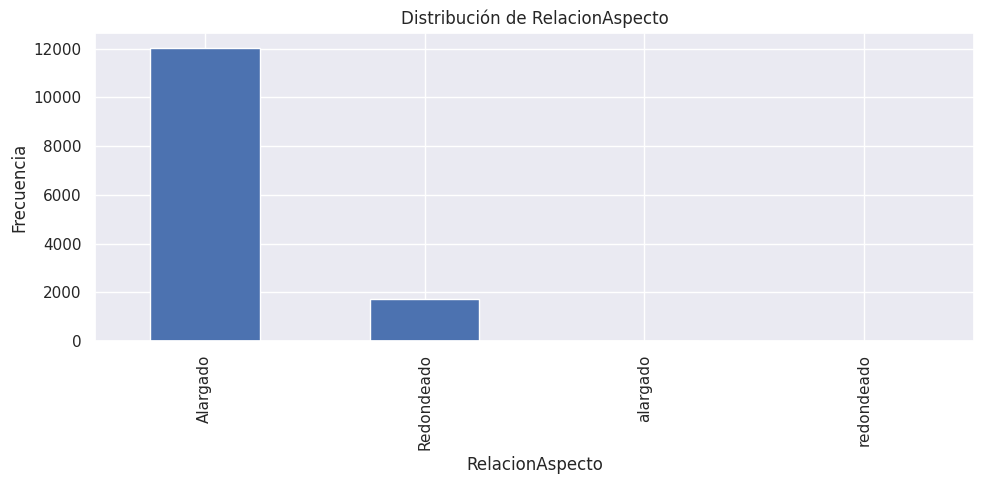

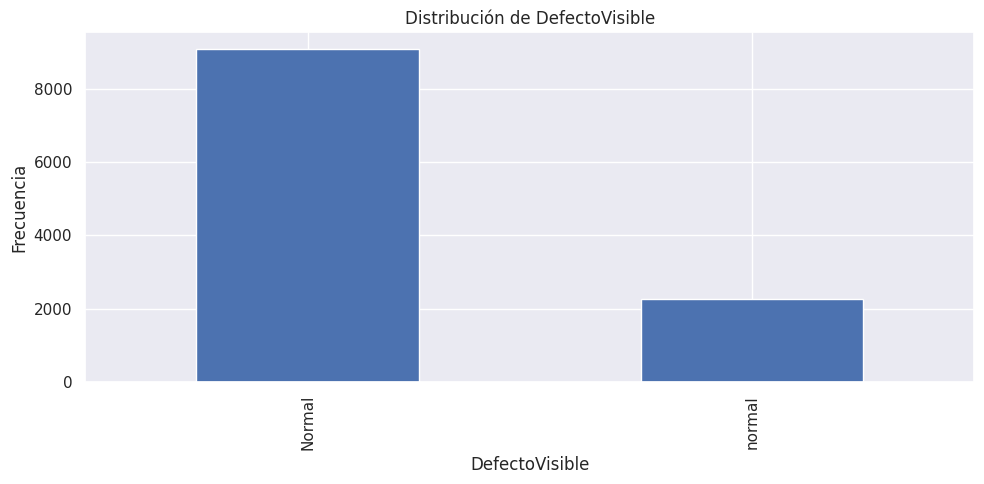

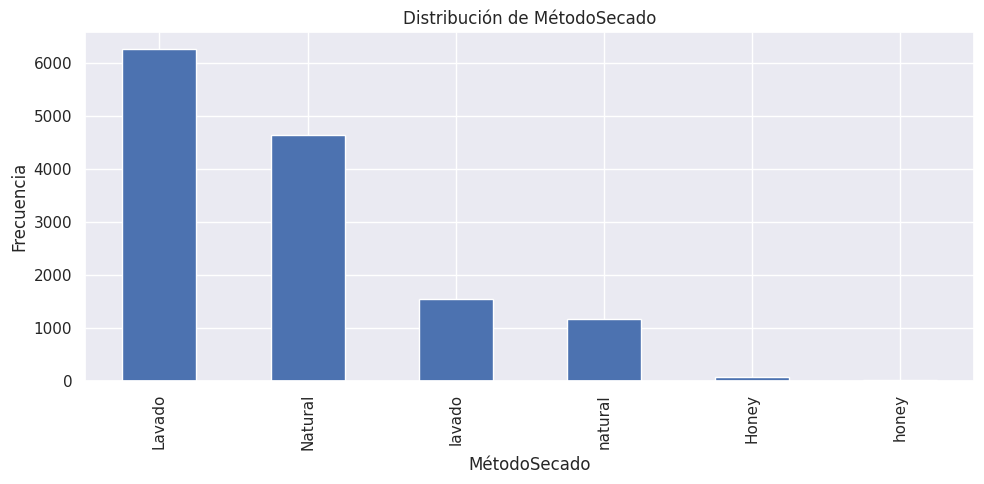

In [10]:
for col in cat_cols:
    if df[col].nunique() <= 20:
        plt.figure(figsize=(10, 5))
        df[col].value_counts().plot(kind="bar")
        plt.title(f"Distribución de {col}")
        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        plt.tight_layout()
        plt.show()

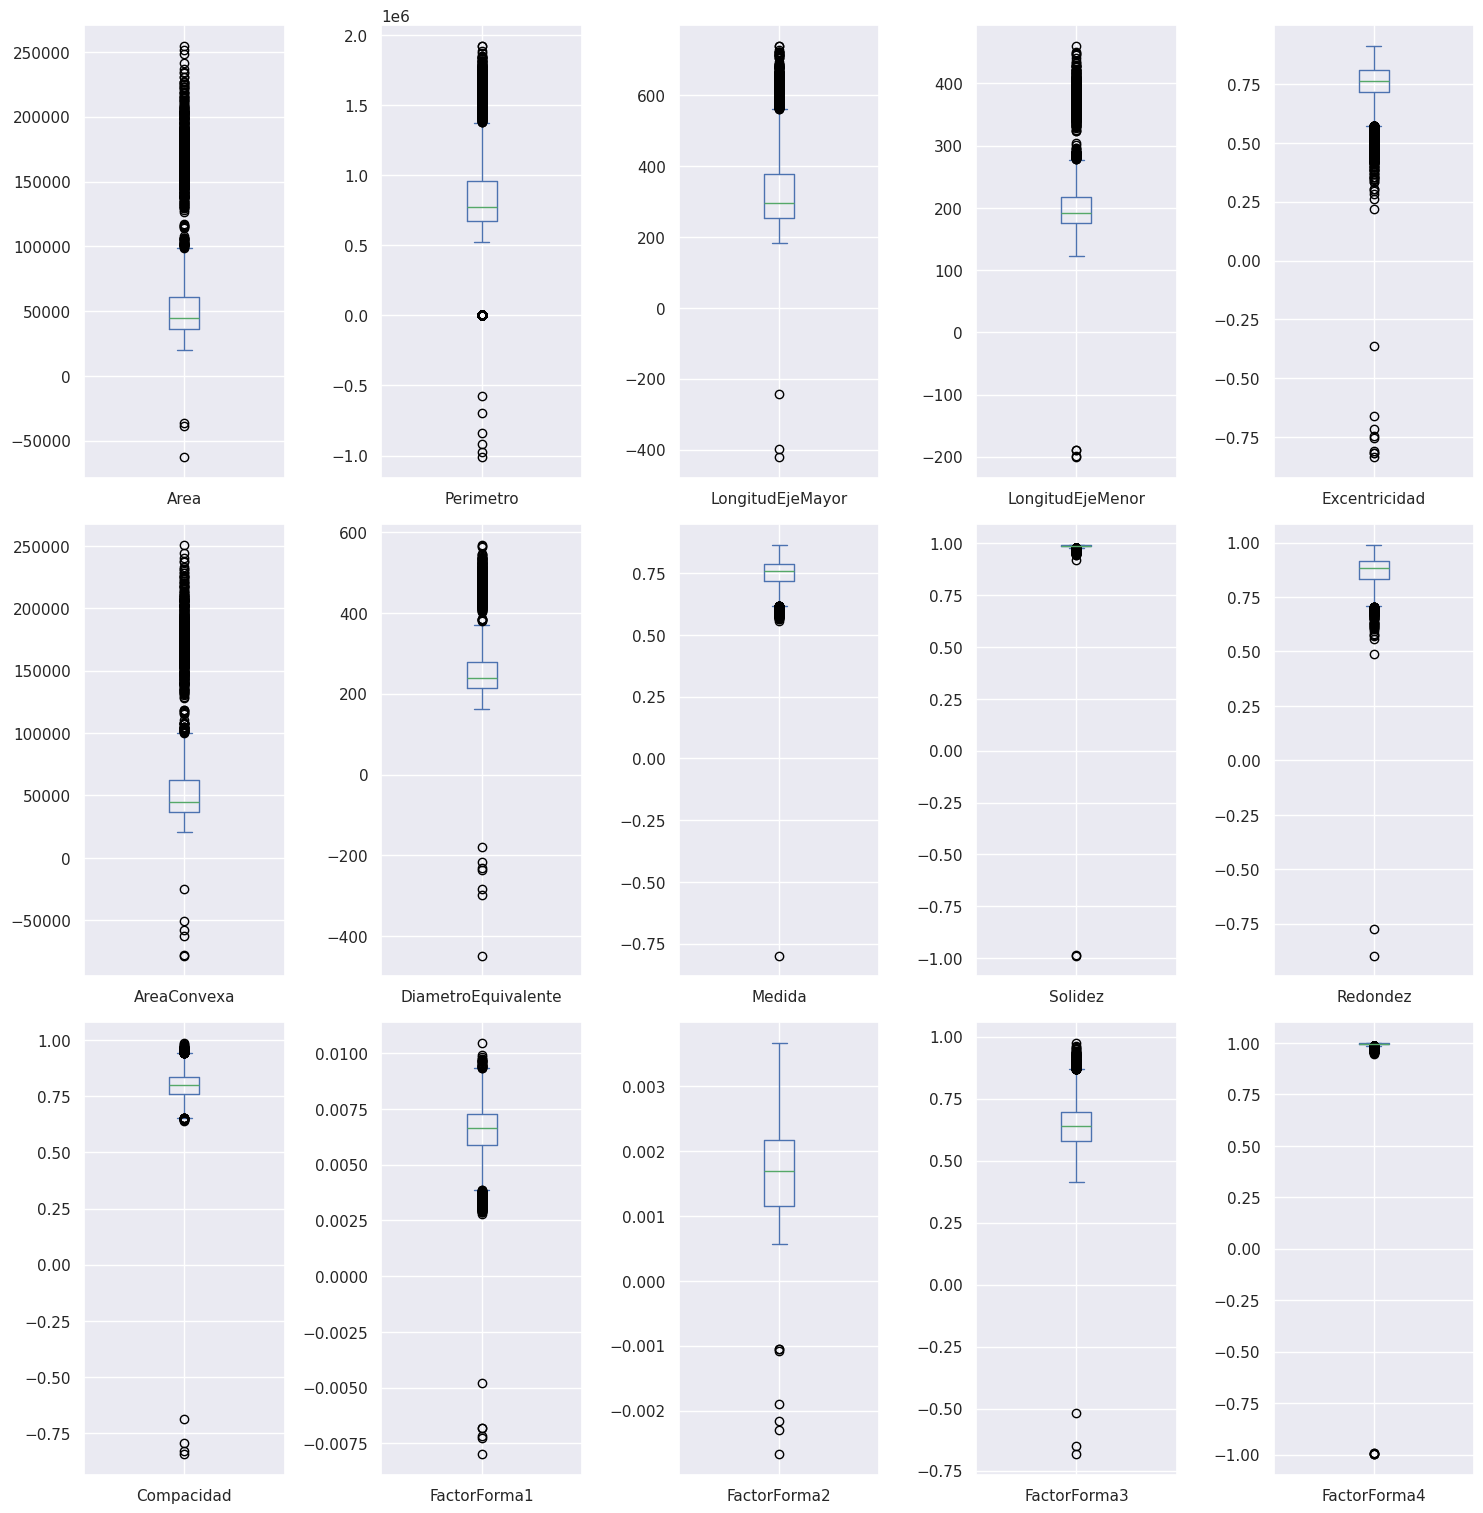

In [11]:
import matplotlib.pyplot as plt

df.plot(
    kind="box",
    subplots=True,
    layout=(int(len(df.columns) / 5) + 1, 5),  # filas, cols
    figsize=(15, 5 * (len(df.columns) // 5 + 1)),
    sharex=False,
    sharey=False,
)

plt.tight_layout()
plt.show()

In [12]:
# Revisar el contenido de las variables que no son numéricas, en este caso son categóricas
df[cat_cols].describe()

,ID,RelacionAspecto,DefectoVisible,MétodoSecado
count,14291,13825,11356,13704
unique,13611,4,2,6
top,G011515,Alargado,Normal,Lavado
freq,2,12047,9096,6260


In [13]:
# Revisar el contenido de las variables que son numéricas
df[num_cols].describe()

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
count,14291.000000,1.305400e+04,13890.000000,14291.000000,13687.000000,12868.000000,12368.000000,14291.000000,11985.000000,12228.000000,13641.000000,13172.000000,13185.000000,13813.000000,13132.000000
mean,53055.408999,7.729870e+05,319.985592,202.178613,0.749977,53575.397809,253.001741,0.749844,0.986774,0.873080,0.799242,0.006560,0.001712,0.643183,0.994292
std,29396.080372,3.266493e+05,86.378452,45.494541,0.099438,29566.387814,60.542330,0.050774,0.025947,0.063237,0.067643,0.001164,0.000601,0.100857,0.039081
min,-62716.000000,-1.012143e+06,-421.444657,-200.838672,-0.835004,-78423.000000,-448.402605,-0.798706,-0.989042,-0.896861,-0.843901,-0.007982,-0.002673,-0.683269,-0.998527
25%,36338.000000,6.768608e+05,253.319858,175.881052,0.715144,36720.000000,215.302463,0.718767,0.985597,0.832824,0.762127,0.005903,0.001151,0.581047,0.993663
50%,44660.000000,7.720345e+05,296.682345,192.437870,0.764392,45107.500000,238.579492,0.760232,0.988279,0.883353,0.800994,0.006645,0.001691,0.641648,0.996377
75%,61311.000000,9.554098e+05,376.548109,216.847844,0.810441,62109.250000,279.672481,0.786942,0.989991,0.916803,0.834405,0.007273,0.002169,0.696366,0.997889
max,254616.000000,1.921685e+06,738.860154,460.198497,0.911423,251082.000000,569.374358,0.866195,0.994378,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


<Figure size 3000x800 with 0 Axes>

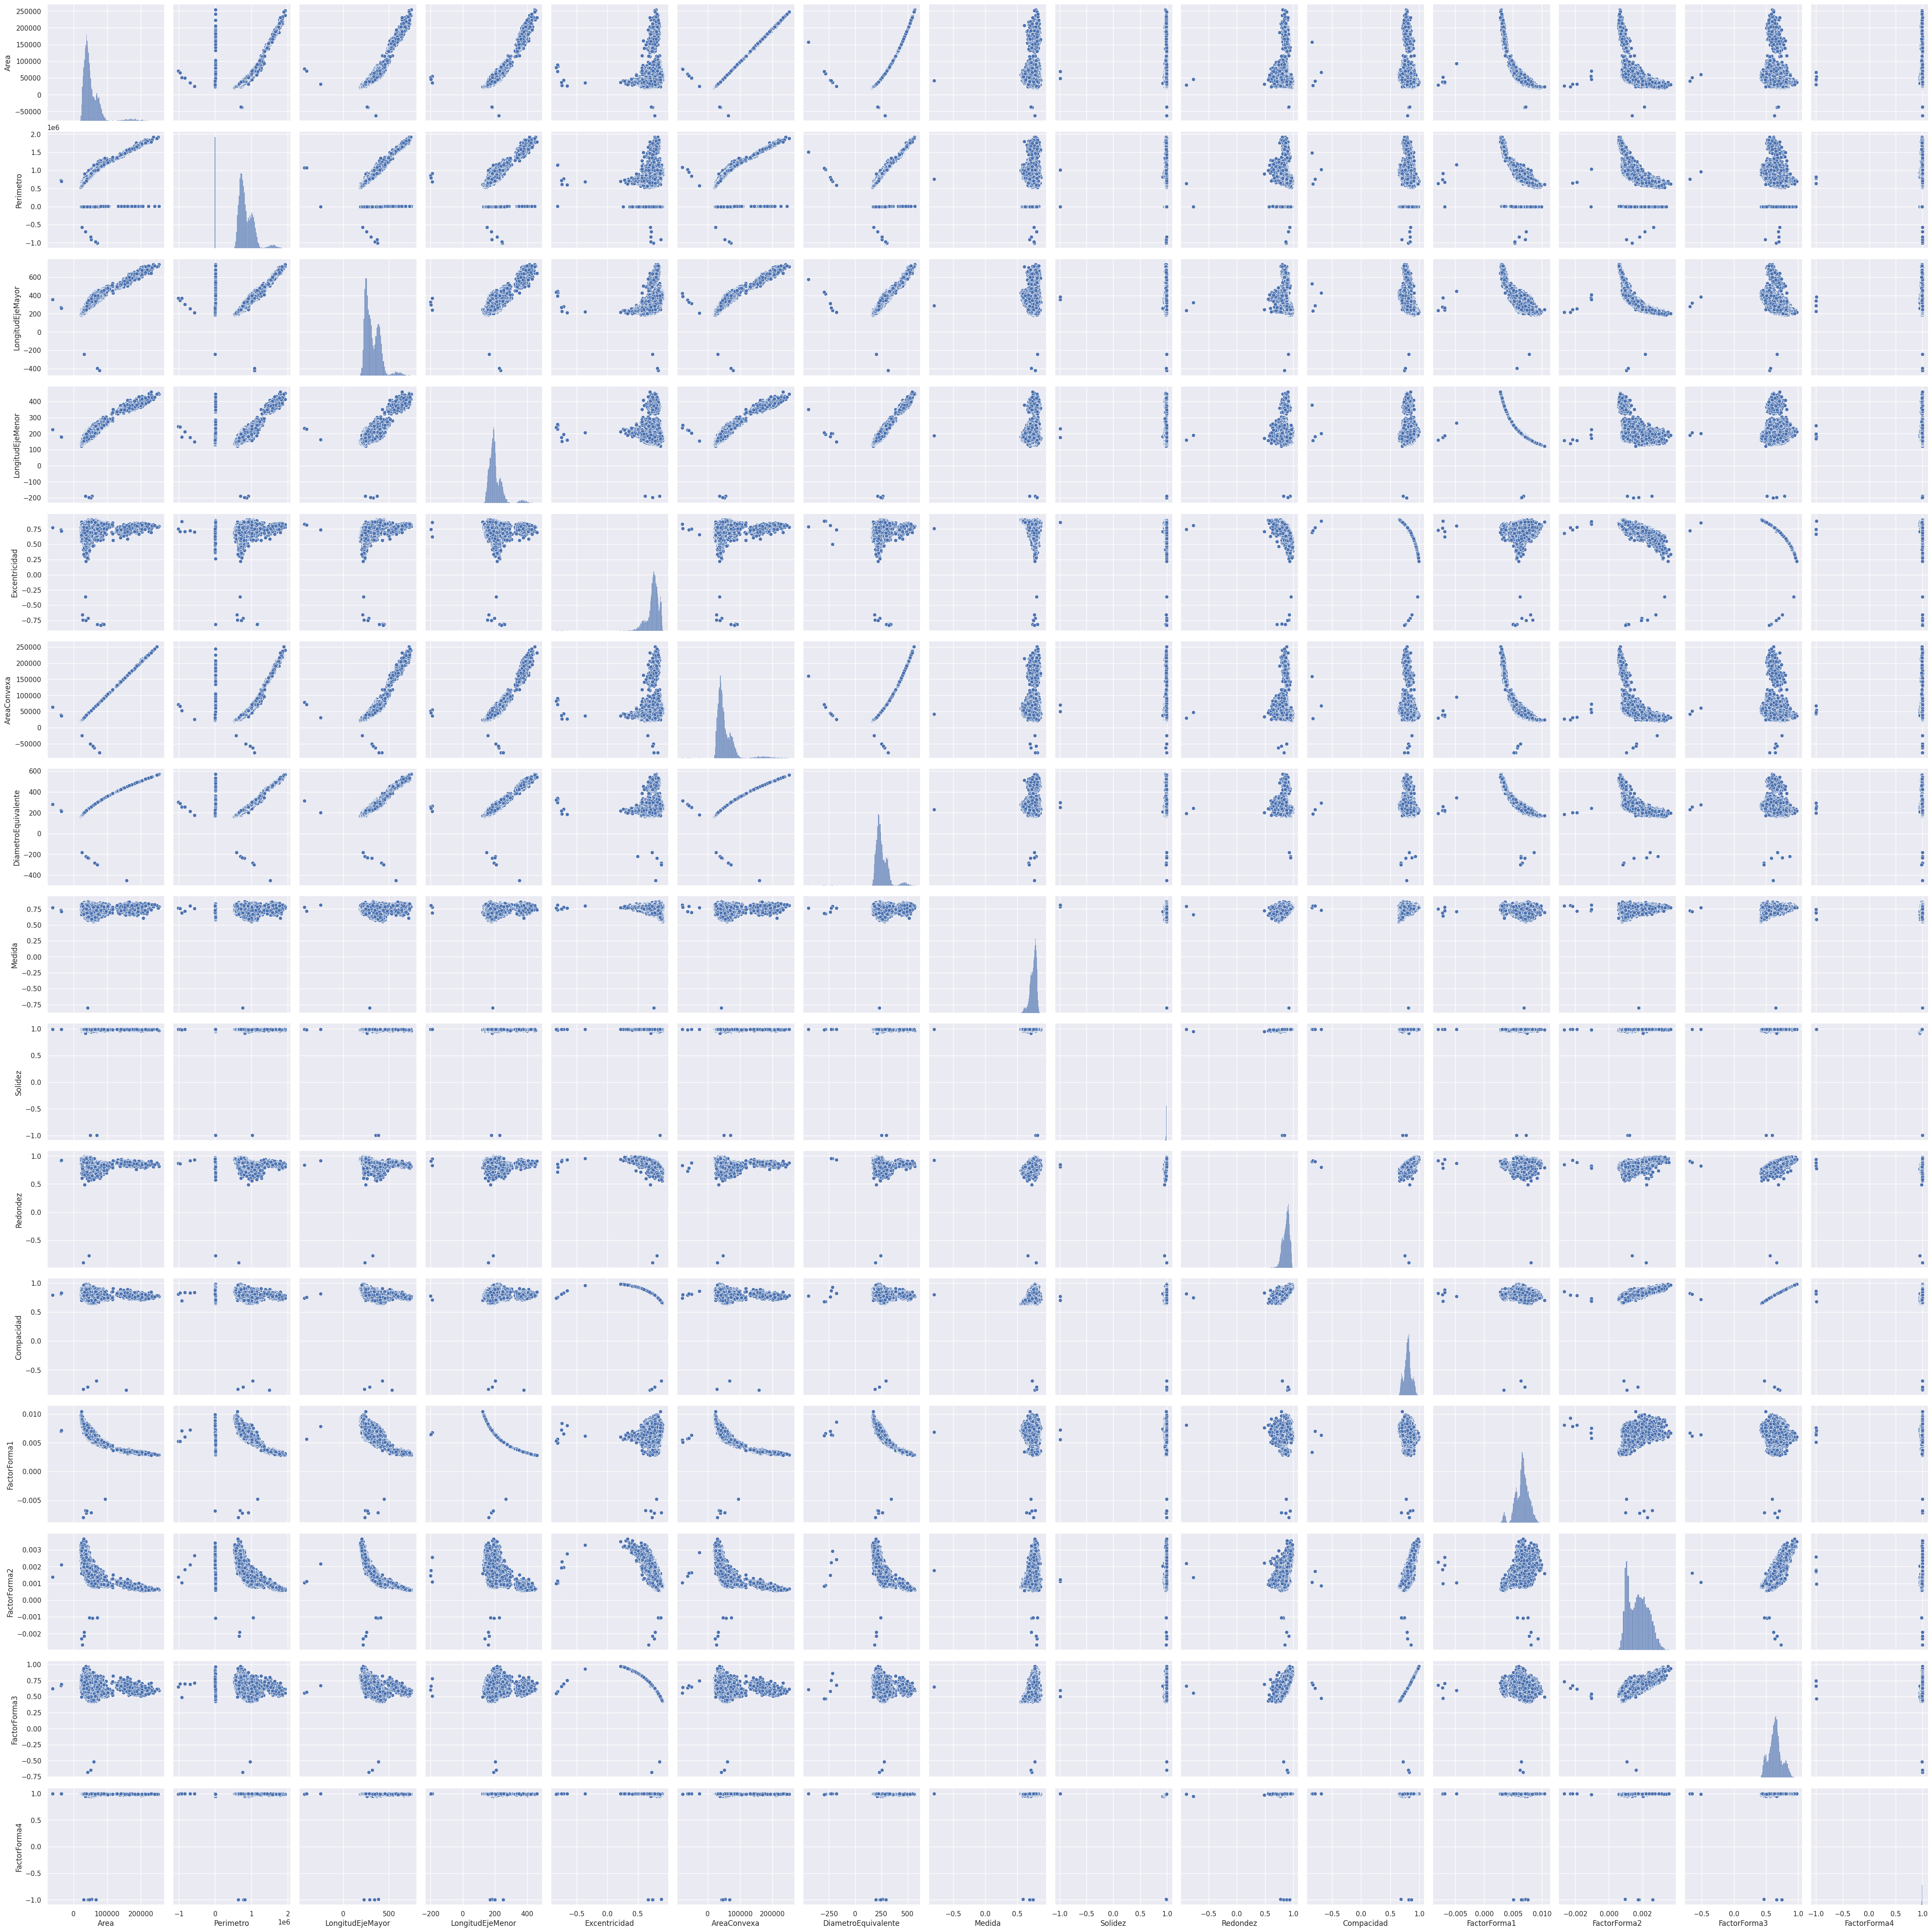

In [14]:
# Vámos las relaciones entre todas las variables numércias
plt.figure(figsize=(30, 8))
sns.pairplot(df[num_cols], height=3)

**Análisis**
1. Observamos que se identifican varios grupos en gran parte de las variables, aproximadamente se observan entre 2 a 3 grupos entre las variables, con 1 o 2 grupos que tienen la mayos parte de los datos
  
2. Las variables categoricas tienes errores de consistencia, donde las caregorias de estas variables tienen el nombre mal escrito y lo toma como otra categoria diferente.

3.

In [16]:
# Consulto una muestra de datos para analizarlos mejor
df_cafe = df.copy()
df_cafe.sample(15)

,ID,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,RelacionAspecto,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4,DefectoVisible,MétodoSecado
13395,G001839,46380,809834.00,308.661656,191.746405,Alargado,0.783637,46786.0,243.007922,0.772228,0.991322,0.888687,0.787295,0.006655,0.001577,0.619834,0.997771,Normal,Lavado
2645,G006828,57230,953606.00,395.409522,184.963068,Alargado,0.883847,57949.0,269.939806,0.614762,0.987593,0.790853,0.682684,0.006909,0.000926,0.466058,0.996327,NaN,Natural
12396,G011580,30930,649455.00,241.790319,164.012905,Alargado,0.734760,31278.0,198.447220,0.852841,0.988874,0.921492,0.820741,0.007817,0.002188,0.673616,0.993055,Normal,NaN
2993,G007747,39428,744798.00,275.556566,183.003381,Alargado,0.747624,39885.0,224.056441,0.715312,0.988542,0.893177,0.813105,0.006989,0.001884,0.661140,0.995509,normal,natural
8473,G005616,41469,792831.00,316.888473,167.517627,Alargado,0.848851,41936.0,229.782442,0.664142,0.988864,0.829034,0.725121,0.007642,0.001303,0.525800,NaN,normal,natural
5570,G000916,38702,708716.00,251.234876,196.429955,Redondeado,0.623457,39004.0,221.984046,0.751072,0.992257,0.968275,0.883572,0.006492,0.002441,0.780699,0.998518,Normal,Lavado
14203,G012991,37062,NaN,265.690992,178.007612,Alargado,0.742379,37449.0,217.229841,0.785711,0.989666,0.915144,0.817603,0.007169,0.001976,NaN,0.997754,Normal,Lavado
7763,G004936,78208,1085393.00,428.263342,236.070838,Alargado,0.834355,79877.0,315.559057,0.729661,0.979105,NaN,0.736834,0.005476,0.000996,0.542925,0.984936,NaN,Natural
8239,G008053,41445,760833.00,282.811624,187.392288,Alargado,0.748969,42088.0,NaN,0.716917,NaN,0.899712,0.812258,NaN,0.001832,0.659763,0.995711,NaN,Natural
9066,G013551,41472,759287.00,293.567969,180.448531,Alargado,0.788781,41853.0,229.790753,0.794483,0.990897,0.903968,0.782751,0.007079,0.001639,0.612700,0.996789,Normal,Lavado


## 2.2. Análisis de calidad de datos

Revisamos las dimensiones de calidad: unicidad, completitud, consistencia, validez.
En particular miramos si se presenta algún problema de calidad relacionado con la dimensión y pensamos en opciones para la corrección.

### 2.2.1 Completitud - Análisis de valores nulos o vacíos

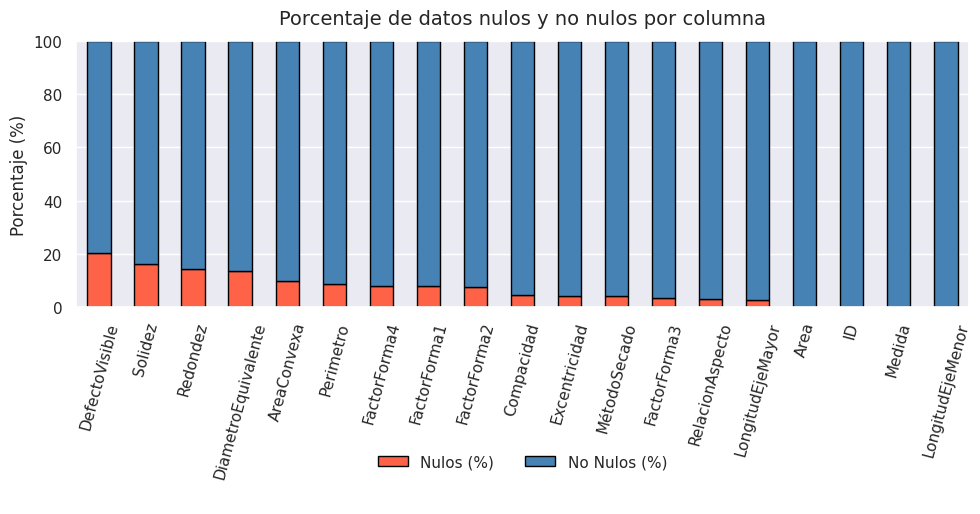

In [17]:
# Cálculo de porcentaje de valores nulos por columna
((df_cafe.isnull().sum() / df_cafe.shape[0])).sort_values(ascending=False)

# Calculamos % de nulos y no nulos
na_percent = df_cafe.isnull().sum() / df_cafe.shape[0] * 100
valid_percent = 100 - na_percent

df_na = pd.DataFrame(
    {"Nulos (%)": na_percent, "No Nulos (%)": valid_percent}
).sort_values("Nulos (%)", ascending=False)

# Gráfico apilado
df_na.plot(kind="bar",stacked=True,color=["tomato", "steelblue"],
           figsize=(10, 6),
            edgecolor="black")

plt.title("Porcentaje de datos nulos y no nulos por columna", fontsize=14, pad=12)
plt.ylabel("Porcentaje (%)", fontsize=12)
plt.xlabel(" ",)
plt.xticks(rotation=75)
plt.ylim(0, 100)  # Siempre hasta 100%
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.5), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

In [18]:
df_cafe.isnull().sum()

,0
ID,0
Area,0
Perimetro,1237
LongitudEjeMayor,401
LongitudEjeMenor,0
RelacionAspecto,466
Excentricidad,604
AreaConvexa,1423
DiametroEquivalente,1923
Medida,0


Ya que sabemos que hay varias columnas que son calculo de otras, entonces vamos a dejar solamente esas columnas a las cuales podriamos llamar como "obligatorias", es decir, que no pueden ser calculadas a partir de otra columna:

#### Variables obligatorias
Estas siempre deben estar presentes y no deberían ser nulas:
- Área  
- Perímetro  
- LongitudEjeMayor  
- LongitudEjeMenor  
- ÁreaConvexa  

Tambien tendremos en cuenta variables como los factores avanzados, que sabemos que dependen de alguna otra caracteristica del grano pero no sabemos exactamente como se calculan y en cambio si pueden ser de utilidad
#### Factores avanzados
Variables sintéticas que combinan métricas, útiles en contextos más complejos:
- Excentricidad
- FactorForma1  
- FactorForma2  
- FactorForma3  
- FactorForma4

In [19]:
columnas_obligatorias = [
    'Area', 'Perimetro', 'LongitudEjeMayor', 'LongitudEjeMenor', 'AreaConvexa'
]
factores_avanzados = [
    'Excentricidad', 'FactorForma1', 'FactorForma2', 'FactorForma3', 'FactorForma4'
]
columnas_categoricas = ['DefectoVisible', 'MétodoSecado']
columnas_numericas = factores_avanzados + columnas_obligatorias
columnas_a_seleccionar = columnas_categoricas + columnas_obligatorias  + factores_avanzados

df_cafe = df_cafe[columnas_a_seleccionar]

df_cafe.dropna(subset = columnas_obligatorias, inplace = True)



In [20]:
df_cafe.isnull().sum()

,0
DefectoVisible,2348
MétodoSecado,464
Area,0
Perimetro,0
LongitudEjeMayor,0
LongitudEjeMenor,0
AreaConvexa,0
Excentricidad,496
FactorForma1,892
FactorForma2,873


In [21]:
df_cafe.head()

,DefectoVisible,MétodoSecado,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,AreaConvexa,Excentricidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
1,NaN,Natural,62764,1003767.0,409.207082,198.330199,64158.0,NaN,0.006520,0.000916,0.477237,0.984666
2,Normal,Natural,59965,994266.0,389.088529,197.967275,60910.0,0.860886,0.006489,0.001018,0.504326,0.991211
3,Normal,Lavado,55035,917.6,379.346822,185.390577,55591.0,0.872446,0.006893,0.001008,0.486941,0.996380
4,Normal,Lavado,39324,737773.0,262.520242,191.176858,39758.0,0.685326,0.006676,0.002174,0.726511,0.997630
5,NaN,Natural,50654,879938.0,357.233899,181.407743,51251.0,0.861468,0.007052,0.001111,NaN,0.995211


Aqui podemos ver que ya hemos tratado con los valores nulos de las variables numericas obligatorias,sin embargo, para las variables numericas "factores avanzados" lo haremos mas adelante, pues vamos a reemplazar los valores con la media de las respectivas columnas. Por ahora, vamos a trabajar con los valores de nulos de las variables categoricas

In [22]:
df_cafe[columnas_categoricas].isnull().sum()

,0
DefectoVisible,2348
MétodoSecado,464


In [23]:
df_cafe['DefectoVisible'].value_counts()

,count
DefectoVisible,
Normal,7268
normal,1814


- Entendemos que la para la variable DefectoVisible, basandonos en el diccionario de datos, que aquellos datos nulos se refieren a la otra categoria posible, es decir, Defectuoso
- Para la variable MetodoSecado crearemos la categoria "Desconocido"

In [24]:
df_cafe['DefectoVisible']=df_cafe['DefectoVisible'].fillna("Defectuoso")
df_cafe['MétodoSecado'] = df_cafe['MétodoSecado'].fillna("Desconocido")

In [25]:
df_cafe.head()

,DefectoVisible,MétodoSecado,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,AreaConvexa,Excentricidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
1,Defectuoso,Natural,62764,1003767.0,409.207082,198.330199,64158.0,NaN,0.006520,0.000916,0.477237,0.984666
2,Normal,Natural,59965,994266.0,389.088529,197.967275,60910.0,0.860886,0.006489,0.001018,0.504326,0.991211
3,Normal,Lavado,55035,917.6,379.346822,185.390577,55591.0,0.872446,0.006893,0.001008,0.486941,0.996380
4,Normal,Lavado,39324,737773.0,262.520242,191.176858,39758.0,0.685326,0.006676,0.002174,0.726511,0.997630
5,Defectuoso,Natural,50654,879938.0,357.233899,181.407743,51251.0,0.861468,0.007052,0.001111,NaN,0.995211





Antes de aplicar tecnicas de agrupacion, es importante manejar valores NA ya que los algoritmos propuestos no pueden manejar los datos incompletos drectamente.

### 2.2.2 Unicidad

En este punto si se tienen las filas idénticas que representa duplicidad de los datos..

In [26]:
antes = df_cafe.shape[0]
df_cafe = df_cafe.drop_duplicates(keep="first")
despues = df_cafe.shape[0]
print("Filas eliminadas:", antes - despues)

Filas eliminadas: 386


In [27]:
# Verificamos que no hayan duplicados
df_cafe.duplicated().sum()

np.int64(0)

### 2.2.3 Consistencia

1. Observamos valores mal escritos en variables como `DefectoVisible`, `MétodoSecado`

In [28]:
# Revisamos los valores de la variable categórica 'DefectoVisible'
df_cafe.DefectoVisible.value_counts()

,count
DefectoVisible,
Normal,6980
Defectuoso,2259
normal,1805


In [29]:
df_cafe["DefectoVisible"] = df_cafe["DefectoVisible"].replace({"normal": "Normal"})
df_cafe.DefectoVisible.value_counts()

,count
DefectoVisible,
Normal,8785
Defectuoso,2259


In [30]:
# Revisamos los valores de la variable categórica 'MétodoSecado'
df_cafe.MétodoSecado.value_counts()

,count
MétodoSecado,
Lavado,4815
Natural,3543
lavado,1255
natural,930
Desconocido,443
Honey,46
honey,12


In [31]:
df_cafe["MétodoSecado"] = df_cafe["MétodoSecado"].replace(
    {"lavado": "Lavado", "natural": "Natural", "honey": "Honey"}
)
df_cafe.MétodoSecado.value_counts()

,count
MétodoSecado,
Lavado,6070
Natural,4473
Desconocido,443
Honey,58


In [32]:
df_cafe.describe()

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,AreaConvexa,Excentricidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
count,11044.000000,1.104400e+04,11044.000000,11044.000000,11044.000000,10566.000000,10178.000000,10200.000000,10669.000000,10144.000000
mean,52859.038754,7.707116e+05,319.272438,201.922682,53538.684444,0.749328,0.006566,0.001720,0.644155,0.994888
std,29201.580643,3.241338e+05,86.137998,45.367719,29714.659307,0.100237,0.001171,0.000598,0.100116,0.020242
min,-38311.000000,-1.012143e+06,-421.444657,-200.838672,-78423.000000,-0.815195,-0.007982,-0.002157,-0.683269,-0.995589
25%,36295.250000,6.769668e+05,253.227334,175.840519,36676.000000,0.714850,0.005919,0.001159,0.583015,0.993763
50%,44523.000000,7.699280e+05,295.915641,192.397343,45026.500000,0.763892,0.006648,0.001704,0.642567,0.996400
75%,60969.250000,9.524692e+05,376.044012,216.205033,61842.000000,0.809610,0.007277,0.002174,0.696879,0.997893
max,248424.000000,1.921685e+06,738.144502,460.198497,251082.000000,0.908167,0.010451,0.003665,0.974767,0.999709


In [33]:
df_cafe.head()

,DefectoVisible,MétodoSecado,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,AreaConvexa,Excentricidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
1,Defectuoso,Natural,62764,1003767.0,409.207082,198.330199,64158.0,NaN,0.006520,0.000916,0.477237,0.984666
2,Normal,Natural,59965,994266.0,389.088529,197.967275,60910.0,0.860886,0.006489,0.001018,0.504326,0.991211
3,Normal,Lavado,55035,917.6,379.346822,185.390577,55591.0,0.872446,0.006893,0.001008,0.486941,0.996380
4,Normal,Lavado,39324,737773.0,262.520242,191.176858,39758.0,0.685326,0.006676,0.002174,0.726511,0.997630
5,Defectuoso,Natural,50654,879938.0,357.233899,181.407743,51251.0,0.861468,0.007052,0.001111,NaN,0.995211


En variables relacionadas con la medida del grano se tiene una escala mucho mayor a lo que deberia ser (`Área`, `Perimetro`, `LongitudEjeMayor`, `LongitudEjeMenor`, `)

### 2.2.4 Validez

Vamos a empezar revisando que los valores de las variables numericas tengan sentido (ej: valores de distancias no pueden ser menores a 0, o aquellos valores medidos en pixeles no puedes ser menores a 1 ni decimales.) A continuacion mostraremos la condicion para cada una de las variables.


#### Condiciones de los atributos

- **ID** → Siempre presente, único por grano.  
- **Área** → Entero ≥ 1 (mínimo un píxel).  
- **Perímetro** → > 0.  
- **LongitudEjeMayor** → > 0.  
- **LongitudEjeMenor** → > 0.  
- **RelaciónAspecto** → > 0 (cociente de longitudes positivas).  
- **Excentricidad** → 0 ≤ valor ≤ 1.  
- **ÁreaConvexa** → ≥ Área y ≥ 1.  
- **FactorForma1, FactorForma2, FactorForma3, FactorForma4** → No tenemos informacion para concluir segun el diccionario de datos.  


Tambien eliminaremos aquellos valores anomalos usando el rango intercuartilico (IQR)

In [34]:
rangos = {
    "Area": (1, np.inf),                   # >= 1
    "Perimetro": (0, np.inf),              # > 0
    "LongitudEjeMayor": (0, np.inf),       # > 0
    "LongitudEjeMenor": (0, np.inf),       # > 0
    "AreaConvexa": (1, np.inf),            # >= 1
    "Excentricidad": (0, 1),               # [0, 1]
}

def eliminar_outliers_iqr(df, cols, k=1.5):
    df_filtrado = df.copy()
    for col in cols:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - k * IQR
            upper = Q3 + k * IQR
            df_filtrado = df_filtrado[(df_filtrado[col] >= lower) & (df_filtrado[col] <= upper)]
    return df_filtrado


df_cafe = eliminar_outliers_iqr(df_cafe, columnas_numericas)


# --- Aplicación de reglas ---
for col, (min_val, max_val) in rangos.items():
    if col in df_cafe.columns:
        df_cafe = df_cafe[(df_cafe[col] >= min_val) & (df_cafe[col] <= max_val)]



In [35]:
df_cafe.describe()

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,AreaConvexa,Excentricidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
count,6113.000000,6.113000e+03,6113.000000,6113.000000,6113.000000,6113.000000,6113.000000,6113.000000,6113.000000,6113.000000
mean,47363.956813,8.189903e+05,307.503346,192.721845,47972.185997,0.760856,0.006773,0.001727,0.636629,0.995810
std,15869.782637,1.545464e+05,63.663993,28.527755,16135.641563,0.072284,0.000954,0.000520,0.085921,0.002631
min,20420.000000,5.247360e+05,183.601165,137.886809,20684.000000,0.573029,0.004629,0.000765,0.416499,0.987592
25%,35640.000000,6.986580e+05,254.316450,172.542499,36029.000000,0.723133,0.006196,0.001251,0.588118,0.994382
50%,43578.000000,7.825650e+05,292.380777,188.654698,44079.000000,0.763897,0.006777,0.001737,0.642849,0.996507
75%,56546.000000,9.428880e+05,365.469643,206.256507,57430.000000,0.806432,0.007410,0.002140,0.688892,0.997811
max,97743.000000,1.306551e+06,482.049644,276.231306,98773.000000,0.908167,0.009307,0.003304,0.818344,0.999709


Aqui tratamos ahora si con los nulos de las variables numericas "factores avanzados"

In [36]:
for col in factores_avanzados:
    if col in df_cafe.columns:
        df_cafe[col] = df_cafe[col].fillna(df_cafe[col].mean())

In [37]:
df_cafe.isnull().sum()

,0
DefectoVisible,0
MétodoSecado,0
Area,0
Perimetro,0
LongitudEjeMayor,0
LongitudEjeMenor,0
AreaConvexa,0
Excentricidad,0
FactorForma1,0
FactorForma2,0


## 2.3 Codificacion columnas categoricas y estandarizacion

A continuacion vamos a aplicar one hot encoder para la columna Metodo secado, y para la columna Defecto vsisible, aplicaremos label encoder al ser solo dos categorias (normal o defectuoso)

In [38]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

def transformar_categoricas(df, columnas_categoricas):
    cat_cols_clave = columnas_categoricas
    for col in cat_cols_clave:
        if col in df.columns:
            if col in ['DefectoVisible']:
                le = LabelEncoder()
                df[col+'_ORD'] = le.fit_transform(df[col].astype(str))
            else:
                dummies = pd.get_dummies(df[col], prefix=col, dtype = 'int64',drop_first=True, )
                df = pd.concat([df, dummies], axis=1)

            if col!= "Content Type":
                df = df.drop(columns=[col])  # elimina la original
    return df

df_cafe = transformar_categoricas(df_cafe, columnas_categoricas)

df_cafe.head()


,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,AreaConvexa,Excentricidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4,DefectoVisible_ORD,MétodoSecado_Honey,MétodoSecado_Lavado,MétodoSecado_Natural
2,59965,994266.0,389.088529,197.967275,60910.0,0.860886,0.006489,0.001018,0.504326,0.991211,1,0,0,1
4,39324,737773.0,262.520242,191.176858,39758.0,0.685326,0.006676,0.002174,0.726511,0.997630,1,0,1,0
6,42293,775769.0,290.699462,185.793277,42758.0,0.769103,0.006873,0.001722,0.637221,0.997021,1,0,0,1
13,38559,741248.0,249.168187,197.847533,39182.0,0.607876,0.006462,0.002493,0.790771,0.995893,1,0,1,0
14,30706,643256.0,236.017779,166.046313,31055.0,0.710663,0.007686,0.002336,0.701849,0.997607,1,0,1,0


Por ultimo, aplicamos la estandarizacion de los datos, para ahora si, poder entrenar nuestros modelos.

In [39]:

num_cols = df_cafe.select_dtypes(include=[np.number]).columns.tolist()

# separar continuas de binarias (para no escalar dummies)
def es_binaria(serie):
    vals = serie.dropna().unique()
    return len(vals) <= 2

cont_cols = [c for c in num_cols if not es_binaria(df_cafe[c])]
bin_cols  = [c for c in num_cols if es_binaria(df_cafe[c])]

scaler_minmax = MinMaxScaler()
scaler_std = StandardScaler()

df_final = df_cafe.copy()
if cont_cols:
    df_final[cont_cols] = scaler_minmax.fit_transform(df_final[cont_cols])
print("\nVariables numéricas normalizadas (MinMax):")
print(df_final[cont_cols].head())


Variables numéricas normalizadas (MinMax):
        Area  Perimetro  LongitudEjeMayor  LongitudEjeMenor  AreaConvexa  \
2   0.511426   0.600564          0.688519          0.434282     0.515130   
4   0.244481   0.272490          0.264431          0.385198     0.244260   
6   0.282878   0.321090          0.358850          0.346284     0.282677   
13  0.234587   0.276935          0.219693          0.433416     0.236884   
14  0.133026   0.151596          0.175630          0.203546     0.132810   

    Excentricidad  FactorForma1  FactorForma2  FactorForma3  FactorForma4  
2        0.858921      0.397604      0.099465      0.218558      0.298642  
4        0.335076      0.437630      0.554614      0.771472      0.828445  
6        0.585054      0.479879      0.376603      0.549272      0.778163  
13       0.103977      0.391919      0.680273      0.931385      0.685046  
14       0.410677      0.653655      0.618424      0.710101      0.826496  


# 3. Modelos

## 3.1 DBSCAN (Andres Ortiz)
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) es un algoritmo de agrupamiento no supervisado que identifica grupos de datos en función de su densidad. A diferencia de otros métodos como K-means, no requiere especificar el número de clusters previamente. DBSCAN se basa en dos parámetros principales: ε (epsilon), que define el radio de vecindad alrededor de un punto, y minPts, que indica el número mínimo de puntos necesarios para formar una región densa.

Los puntos se clasifican en tres categorías:
* Puntos núcleo: tienen al menos minPts dentro de su radio ε.
* Puntos frontera: no cumplen la condición de núcleo pero están dentro de la vecindad de un punto núcleo.
* Ruido: puntos que no pertenecen a ningún cluster.

Este enfoque permite detectar clusters de forma arbitraria y manejar valores atípicos de manera natural.

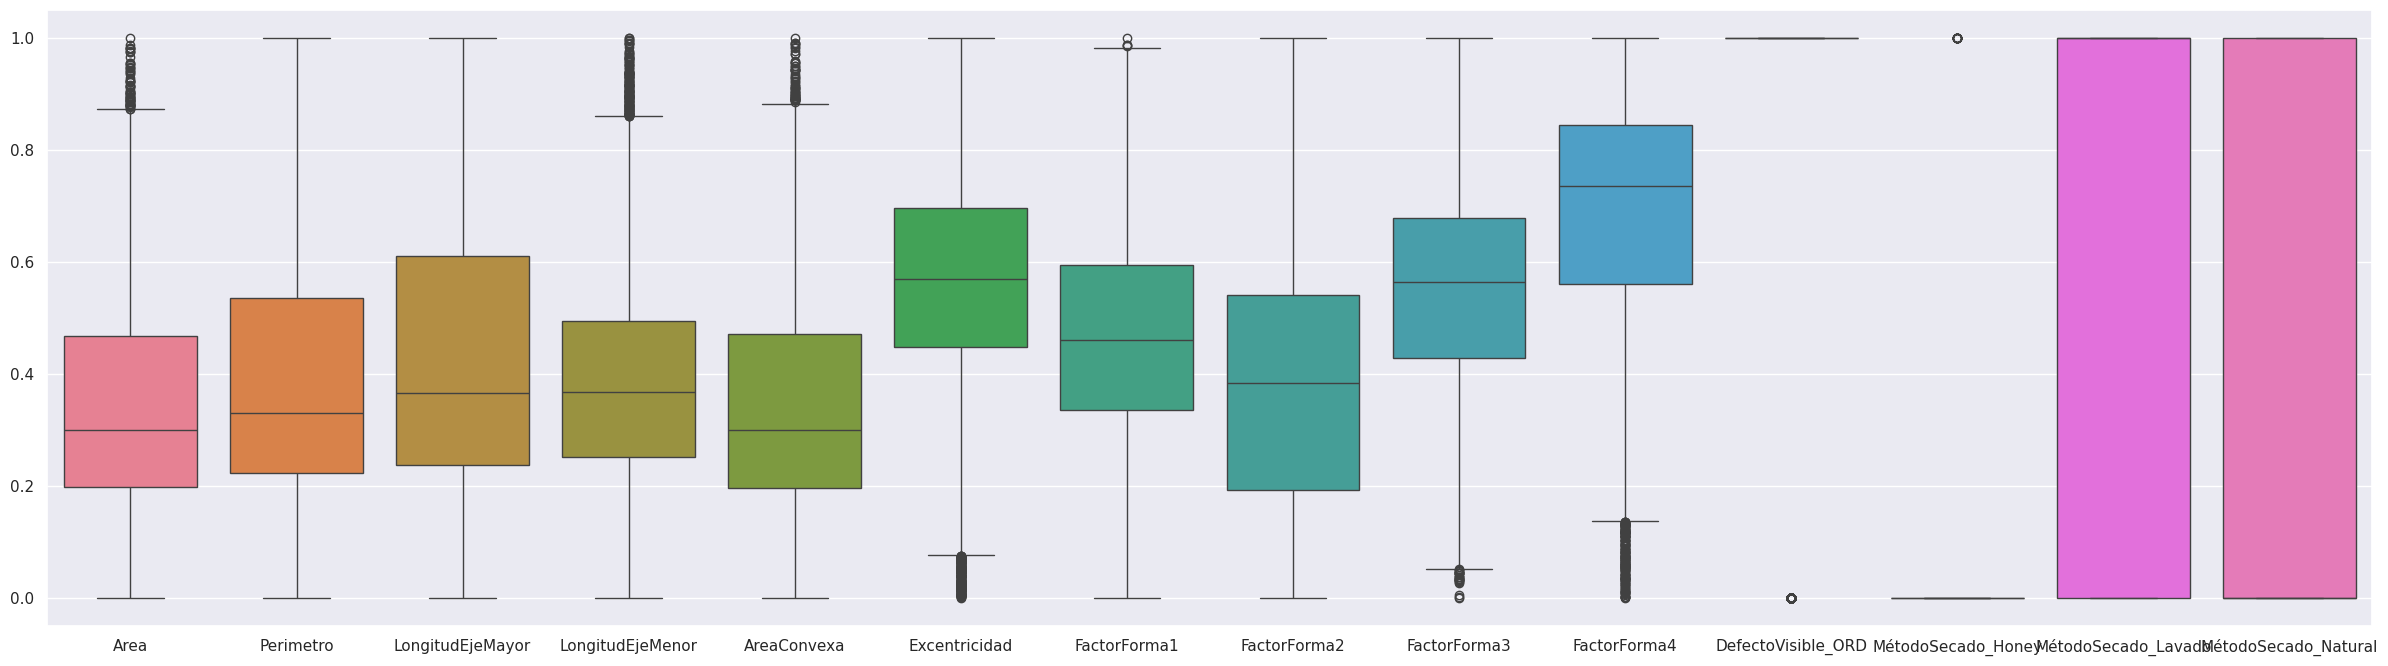

In [41]:
#Visualización de todas las variables numéricas de tpo int luego de la transformación
fig=plt.figure(figsize=(30,8))
ax = sns.boxplot(data=df_final, orient="v")

### 3.1.1 Selección de min_samples

In [42]:
X = df_final

n_rows, n_cols = X.shape

print(f"The number of rows: {n_rows}")
print(f"The number of columns: {n_cols}")

The number of rows: 6113
The number of columns: 14


Para seleccionar el valor de `min_samples`, se toman valores entre `n_cols` y `2*n_cols`

In [ ]:
min_samples_grid = [14, 16, 18, 20, 22, 24, 28]

👀 Si ponemos valores entre 2-10, va a ser muy suave y todo será un cluster. Pero por otro lado, si ponemos valores muy grandes, va a ser muy estricto y va a clasificar la mayoría de puntos como ruido.

### 3.1.2 Selección de ε

Otra parte importante para este modelo es el valor de ε que indica la distancia entre dos puntos para que se consideren vecinos.

. Why eps matters
eps defines the neighborhood size around each point.
Small eps → many points isolated as noise.
Large eps → clusters merge together (even all into one).
The “sweet spot” is dataset-dependent — you can’t guess it by hand.

* Un valor pequeño de ε causara muchos puntos aislados
* Un valor grande de ε causara que agrupaciones se fusionen entre ellas

🚨 Para encontrar un punto adecuado de ε, toca

In [ ]:
# seleccionar K tal que sea la media de min_samples_grid
k = int(np.median(min_samples_grid))
print("K: ", k)

K:  20


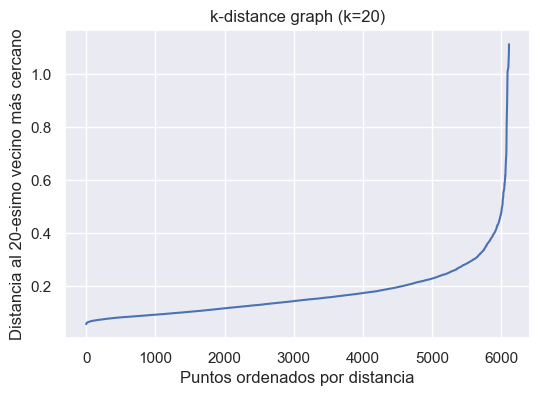

eps candidates: [0.1981 0.2201 0.2421 0.2445 0.2559 0.269  0.2723 0.2844 0.3026 0.3128
 0.3247 0.3328 0.3608 0.3735 0.3968 0.4151 0.4566 0.5305 0.5894 0.6484]


In [ ]:
# encontrar los vecinos con KNN
vecinos = NearestNeighbors(n_neighbors=k).fit(X)
distancias, _ = vecinos.kneighbors(X)

# las distancias a los k-esimos vecinos
k_dists = np.sort(distances[:, -1])

# graficar la curva de distancias
plt.figure(figsize=(6, 4))
plt.plot(k_dists)
plt.xlabel("Puntos ordenados por distancia")
plt.ylabel(f"Distancia al {k}-esimo vecino más cercano")
plt.title(f"k-distance graph (k={k})")
plt.grid(True)
plt.show()

# --- quantiles como candidatos al epsilon ---
q = np.quantile(k_dists, [0.80, 0.85, 0.90, 0.92, 0.95, 0.97, 0.99])
eps_candidates = np.unique(np.round(np.concatenate([q * 0.9, q, q * 1.1]), 4))

print("eps candidates:", eps_candidates)

In [ ]:
# escogiendo un quantil de 95%, sacamos el valor de ε
eps_auto = np.quantile(k_dists, 0.95)
print("ε (percentil 95%):", eps_auto)

ε (percentil 95%): 0.36075466091719544


### 3.1.3 Seleccionar hiperparametros

In [ ]:
param_grid = {
    "min_samples": min_samples_grid,
    "eps": [0.3328, 0.3608, 0.3735, 0.3968],
}

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

results = []

for m in param_grid["min_samples"]:
    for e in param_grid["eps"]:
        model = DBSCAN(eps=e, min_samples=m)
        labels = model.fit_predict(X)

        mask = labels != -1
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.mean(labels == -1)

        if mask.sum() > 1 and n_clusters > 1:
            sil = silhouette_score(X[mask], labels[mask])
        else:
            sil = None

        results.append(
            {
                "eps": e,
                "min_samples": m,
                "clusters": n_clusters,
                "noise_ratio": noise_ratio,
                "silhouette": sil
            }
        )

df_results = pd.DataFrame(results)
print(df_results.sort_values("silhouette", ascending=False).to_string())


       eps  min_samples  clusters  noise_ratio  silhouette
7   0.3968           16         5     0.011778    0.385091
11  0.3968           18         5     0.012105    0.384860
15  0.3968           20         5     0.012269    0.384788
6   0.3735           16         5     0.012923    0.384190
5   0.3608           16         5     0.013250    0.383817
10  0.3735           18         5     0.013087    0.383788
19  0.3968           22         5     0.013087    0.383592
9   0.3608           18         5     0.014232    0.382935
14  0.3735           20         5     0.015050    0.380678
4   0.3328           16         5     0.015704    0.379932
13  0.3608           20         5     0.016686    0.376492
3   0.3968           14         6     0.008670    0.374348
2   0.3735           14         6     0.009652    0.373789
23  0.3968           24         5     0.016031    0.373246
1   0.3608           14         6     0.010469    0.373056
18  0.3735           22         5     0.017831    0.3717

In [ ]:
best = df_results.loc[df_results["silhouette"].idxmax()]
print("Best config:")
print(best)

Best config:
eps             0.396800
min_samples    16.000000
clusters        5.000000
noise_ratio     0.011778
silhouette      0.385091
Name: 7, dtype: float64


Despues del analisis de hiperparametros, el mejor model es el que usa `ε = 0.39680` con `min_samples = 16` lo cual nos da un `silhoutte = 0.385091`.

### 3.1.4 Encontrar mejor modelo

In [ ]:
best_min_samples = int(best["min_samples"])

best_model = DBSCAN(eps=best_eps, min_samples=best_min_samples)
best_labels = best_model.fit_predict(X)

In [ ]:
counts = pd.Series(best_labels).value_counts().sort_index()
print(counts)

-1      72
 0    2129
 1    2548
 2     546
 3     634
 4     184
Name: count, dtype: int64


### 3.1.5 Visualización silhouette

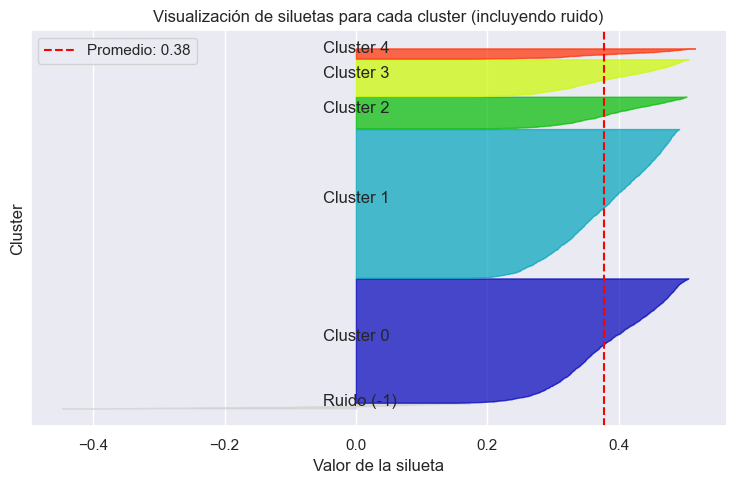

In [ ]:
cluster_labels = dbscan.labels_
silhouette_vals = silhouette_samples(X, cluster_labels)
silhouette_avg = silhouette_score(X, cluster_labels)
unique_clusters = np.unique(cluster_labels)

import matplotlib.cm as cm

plt.figure(figsize=(8, 5))
y_lower = 10
silhouette_avg = silhouette_score(X, cluster_labels)
silhouette_vals = silhouette_samples(X, cluster_labels)

for i, c in enumerate(unique_clusters):
    ith = silhouette_vals[cluster_labels == c]
    ith.sort()
    size_i = ith.shape[0]
    y_upper = y_lower + size_i

    color = "lightgray" if c == -1 else cm.nipy_spectral(float(i) / len(unique_clusters))
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith, facecolor=color, edgecolor=color, alpha=0.7)

    label = "Ruido (-1)" if c == -1 else f"Cluster {c}"
    plt.text(-0.05, y_lower + 0.5 * size_i, label)

    y_lower = y_upper + 10

plt.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Promedio: {silhouette_avg:.2f}")
plt.xlabel("Valor de la silueta")
plt.ylabel("Cluster")
plt.title("Visualización de siluetas para cada cluster (incluyendo ruido)")
plt.tight_layout()
plt.yticks([])
plt.legend()
plt.show()

Un valor de 0.38 para la silueta indica que hay separación moderada entre los grupos identificados por DBSCAN. Hay 5 grupos principales y algunos fatos de ruido representados con valores negativos. Sin embargo, los resultados son aceptables aunque los grupos no presentan una separación muy marcada.

### 3.1.5 Visualización el resultado

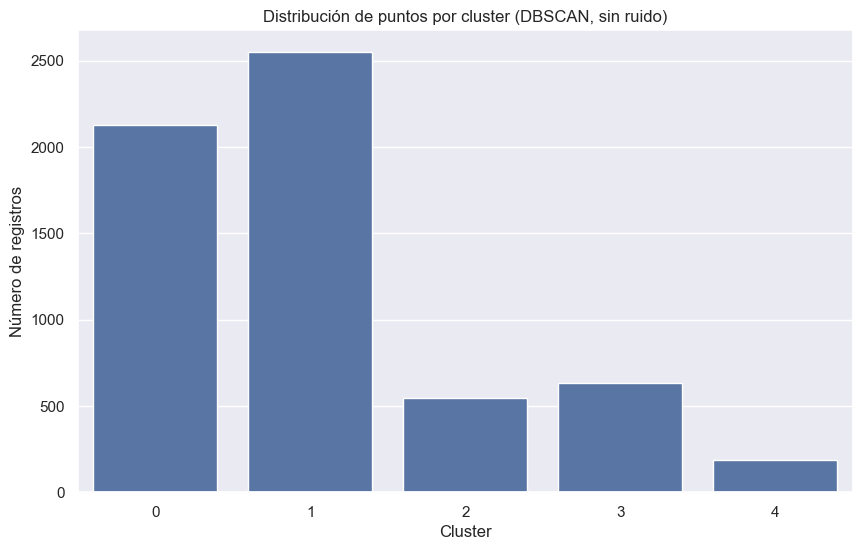

In [ ]:
# Revisar la cantidad de registros en los clústeres resultado
df_dbscan = df_final.copy()
df_dbscan['Cluster'] = labels

cluster_distrib = df_dbscan["Cluster"].value_counts().sort_index()
cluster_distrib = cluster_distrib.drop(-1, errors="ignore")

plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_distrib.index, y=cluster_distrib.values, color="b")
plt.title("Distribución de puntos por cluster (DBSCAN, sin ruido)")
plt.xlabel("Cluster")
plt.ylabel("Número de registros")
plt.show()


## 3.2 Segundo modelo: K-means (Juan Esteban Quiroga)
Para este modelo utilizaremos el algoritmo K-means o tambien llamado Lloyd–Forgy para la tarea de agrupacion, a continuacion vamos a ver los criterios para la seleccion del modelo.

- El algoritmo k-means es un algoritmo eficiente y muy rapido, lo que nos permitira encontrar rapidamente el numero k mas optimo.
- No es necesario hacer mas adecuaciones a los datos de los que ya hicimos en la seccion de preparacion y entendimiento de los datos.
- El algoritmo responde al objetivo de la tarea (clustering).
- Se esperan datos de tamaño esferico o similares, lo que funciona bien con el algoritmo de k-means


### 3.2.1 Encontrar el k optimo

In [ ]:
df_processed = df_cafe.copy()

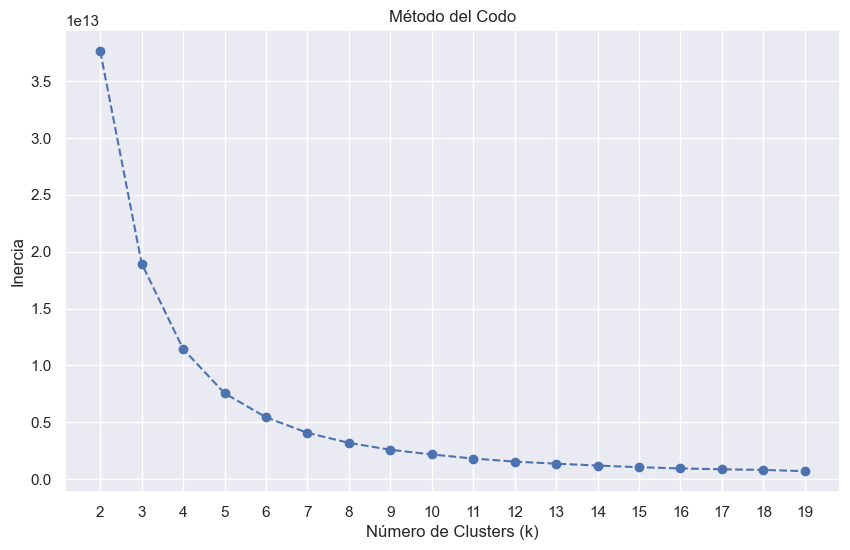

In [ ]:
inertia = []
k_range = range(2, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_processed)
    inertia.append(kmeans.inertia_)

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.xticks(k_range)
plt.grid(True)
plt.show()

Para este caso tomaremos el k=5 como el 'Codo' o el k optimo. Pues se genera el cambio de direccion mas evidente.

### 3.2.2 Entrenamiento del modelo

In [ ]:
k_optimo = 5

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init='auto')
clusters = kmeans_final.fit_predict(df_processed)


df_processed['cluster'] = clusters
df_kmeans = df_processed.copy()
print(f"\n--- Se encontraron {k_optimo} clusters. Primeras 5 filas con su cluster asignado: ---")
print(df_processed.head())

cluster_analysis = df_processed.groupby('cluster').mean()


--- Se encontraron 5 clusters. Primeras 5 filas con su cluster asignado: ---
     Area  Perimetro  LongitudEjeMayor  LongitudEjeMenor  AreaConvexa  \
2   59965   994266.0        389.088529        197.967275      60910.0   
4   39324   737773.0        262.520242        191.176858      39758.0   
6   42293   775769.0        290.699462        185.793277      42758.0   
13  38559   741248.0        249.168187        197.847533      39182.0   
14  30706   643256.0        236.017779        166.046313      31055.0   

    Excentricidad  FactorForma1  FactorForma2  FactorForma3  FactorForma4  \
2        0.860886      0.006489      0.001018      0.504326      0.991211   
4        0.685326      0.006676      0.002174      0.726511      0.997630   
6        0.769103      0.006873      0.001722      0.637221      0.997021   
13       0.607876      0.006462      0.002493      0.790771      0.995893   
14       0.710663      0.007686      0.002336      0.701849      0.997607   

    DefectoVisible_O


--- DataFrame reducido a 2D con PCA (primeras 5 filas): ---
   Componente Principal 1  Componente Principal 2  cluster
0           176058.539837            -7150.352635        2
1           -82026.354208              219.854123        1
2           -43816.992193            -1027.191132        1
3           -78722.170872            -1215.520018        1
4          -177323.736919             1591.253271        4


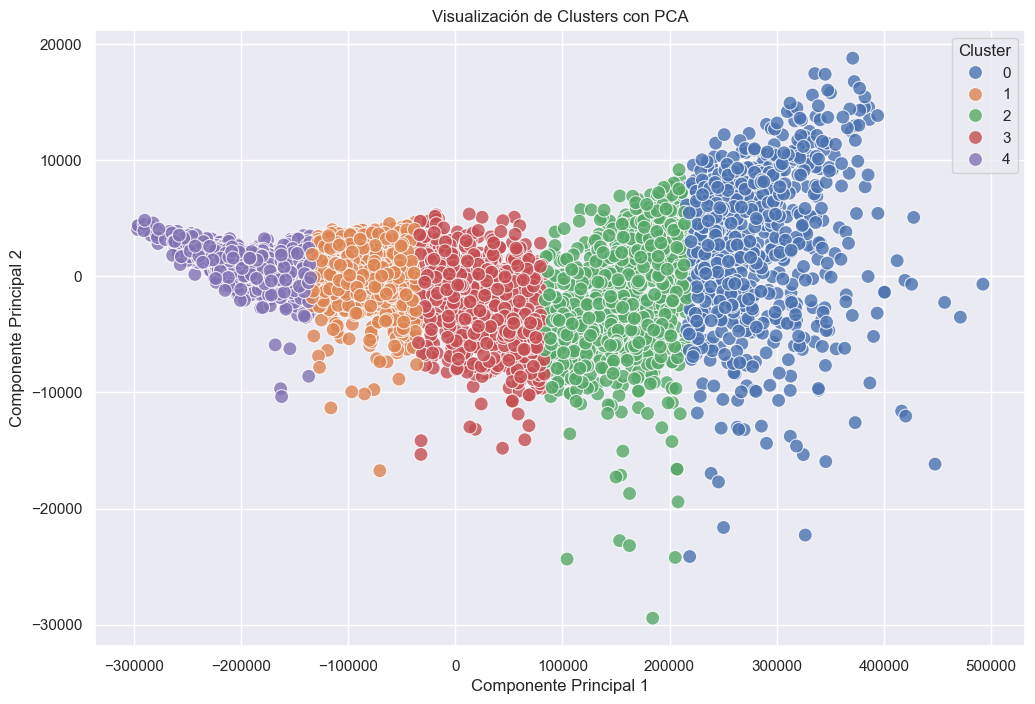

In [ ]:
from sklearn.decomposition import PCA


features_para_pca = df_processed.drop('cluster', axis=1)


pca = PCA(n_components=2)
componentes_principales = pca.fit_transform(features_para_pca)


df_pca = pd.DataFrame(data=componentes_principales, columns=['Componente Principal 1', 'Componente Principal 2'])


df_pca['cluster'] = clusters

print("\n--- DataFrame reducido a 2D con PCA (primeras 5 filas): ---")
print(df_pca.head())



plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="Componente Principal 1",
    y="Componente Principal 2",
    hue="cluster",
    data=df_pca,
    palette="deep",
    s=100,
    alpha=0.8
)

plt.title('Visualización de Clusters con PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### 3.2.3 Visualización silhouette

El Coeficiente de Silueta para el modelo final (k=5) es: 0.5318


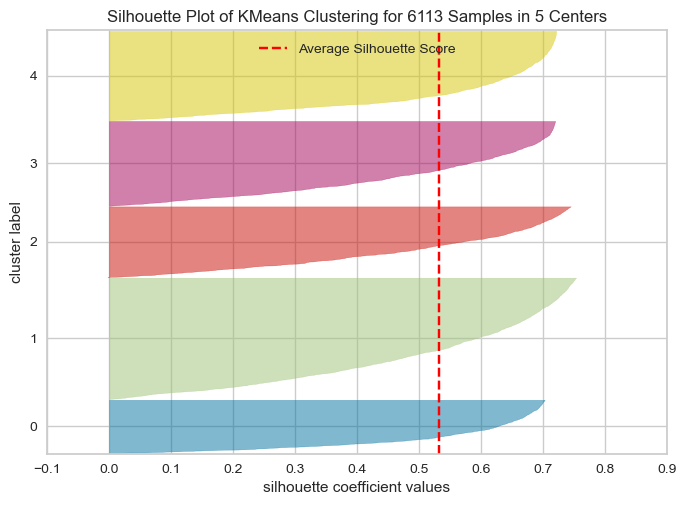

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 6113 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.cluster import KMeans


kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init='auto')

visualizer = SilhouetteVisualizer(kmeans_final, colors='yellowbrick')
visualizer.fit(df_processed)
score = silhouette_score(df_processed, clusters)

print(f"El Coeficiente de Silueta para el modelo final (k=5) es: {score:.4f}")
visualizer.show()

Este grafico nos indica varias cosas positivas a cerca de la efectividad de nuestro modelo:

- No hay valores negativos para ninguno de los clusters, mostrando que probablemente los clusters no fueron asignados al cluster incorrecto.
- Los cinco clusters están bien definidos y son diferentes entre sí.

### 3.2.4 Visualizacion de resultados

--- Número de granos por cluster ---
cluster
0     777
1    1770
2    1029
3    1235
4    1302
Name: count, dtype: int64


C:\Users\juan_\AppData\Local\Temp\ipykernel_16152\3612973353.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')


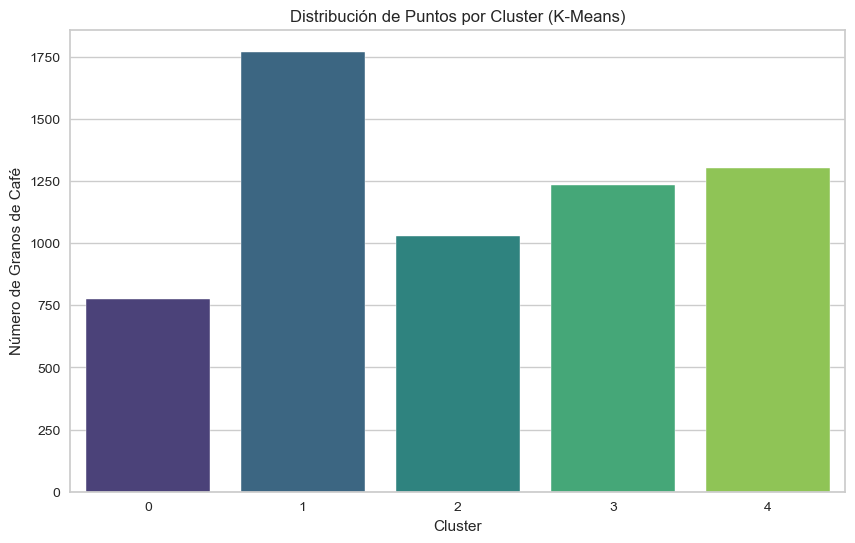

In [ ]:
cluster_counts = df_kmeans['cluster'].value_counts().sort_index()

print("--- Número de granos por cluster ---")
print(cluster_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')

plt.title("Distribución de Puntos por Cluster (K-Means)")
plt.xlabel("Cluster")
plt.ylabel("Número de Granos de Café")
plt.show()

## 3.3 Gaussian Mixture Models (GMM) (Carlos Díaz Vargas)


Para el tercer modelo se eligió el de **Mezclas Gaussianas (GMM)** por su capacidad para encontrar grupos con formas flexibles (elípticas) y no solo circulares. A diferencia de otros métodos, GMM no asigna un grano a un único grupo, sino que calcula la probabilidad de que pertenezca a cada uno, lo que le permite manejar mejor los casos donde las características de los granos se superponen.

La decisión más importante fue elegir el número de grupos (`n_components`). Para ello, se probó con varios valores (de 2 a 10) y se evaluó cada opción usando los criterios AIC y BIC. El gráfico de resultados mostró un "codo" claro en 5 grupos, indicando que este era el punto de equilibrio óptimo entre ajuste y simplicidad. Por lo tanto, se configuró el modelo final con **`n_components=5`**.

Adicionalmente, se usó `covariance_type='full'` para dar máxima flexibilidad al modelo en la forma de los clústeres y `random_state=42` para que los resultados fueran reproducibles.

El modelo final con 5 clústeres obtuvo un **coeficiente de silueta de 0.3654**, lo que indica una separación de grupos aceptable. Este valor sugiere que, aunque los grupos están definidos, existe cierta superposición entre ellos, lo cual es esperable en datos biológicos como la morfología de los granos de café.

La distribución de registros por grupo fue la siguiente:
*   **Clúster 0:** 1128
*   **Clúster 1:** 1835
*   **Clúster 2:** 1547
*   **Clúster 3:** 1135
*   **Clúster 4:** 468

La distribución de tamaños es variada, lo que demuestra que el algoritmo fue capaz de identificar tanto grupos grandes y comunes como uno más pequeño y específico (el Clúster 4).

Buscando el número óptimo de clústeres usando AIC y BIC...


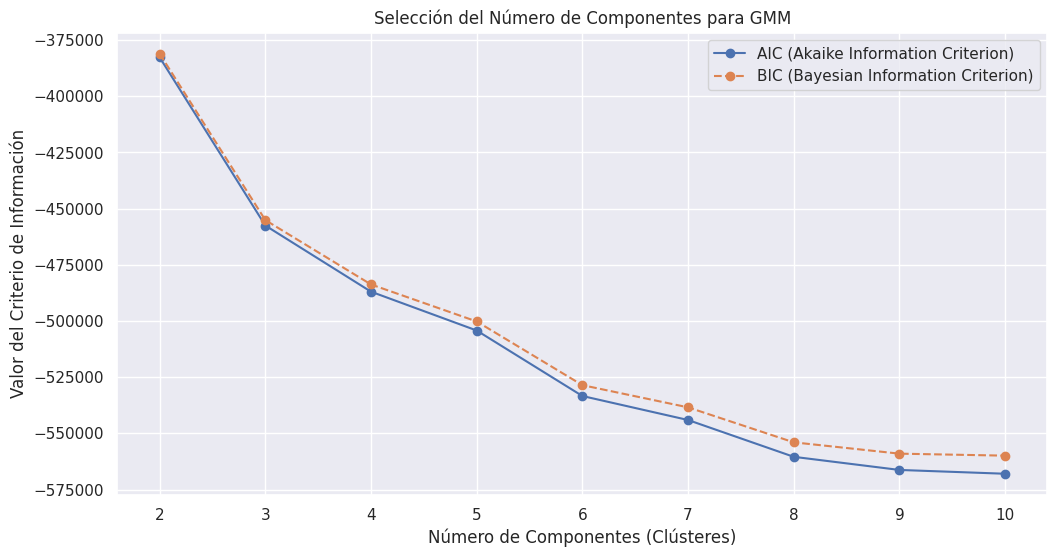

In [43]:

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Buscando el número óptimo de clústeres usando AIC y BIC...")

n_components_range = range(2, 11)
aic_scores = []
bic_scores = []

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
    gmm.fit(X)

    aic_scores.append(gmm.aic(X))
    bic_scores.append(gmm.bic(X))

plt.figure(figsize=(12, 6))
plt.plot(n_components_range, aic_scores, marker='o', linestyle='-', label='AIC (Akaike Information Criterion)')
plt.plot(n_components_range, bic_scores, marker='o', linestyle='--', label='BIC (Bayesian Information Criterion)')
plt.title('Selección del Número de Componentes para GMM')
plt.xlabel('Número de Componentes (Clústeres)')
plt.ylabel('Valor del Criterio de Información')
plt.xticks(n_components_range)
plt.legend()
plt.grid(True)
plt.show()


In [44]:
numero_optimo_clusters = 5

print(f"\nNúmero de clústeres seleccionado: {numero_optimo_clusters}")

best_gmm = GaussianMixture(n_components=numero_optimo_clusters, covariance_type='full', random_state=42)
gmm_labels = best_gmm.fit_predict(X)


Número de clústeres seleccionado: 5


In [45]:
silhouette_avg = silhouette_score(X, gmm_labels)
print(f"El coeficiente de silueta promedio para {numero_optimo_clusters} clústeres es: {silhouette_avg:.4f}")

# Contar el número de puntos en cada clúster
print("\nDistribución de registros por clúster:")
print(pd.Series(gmm_labels).value_counts().sort_index())

El coeficiente de silueta promedio para 5 clústeres es: 0.3654

Distribución de registros por clúster:
0    1128
1    1835
2    1547
3    1135
4     468
Name: count, dtype: int64


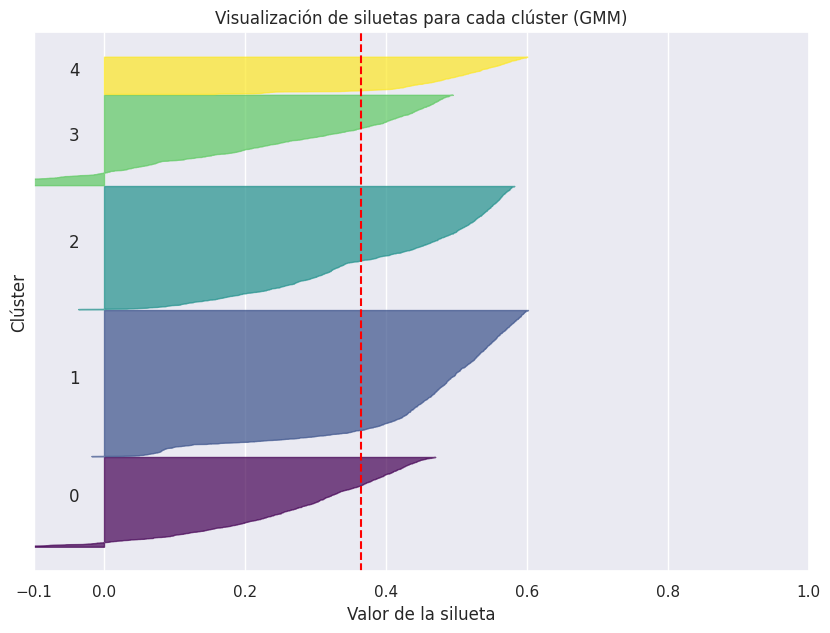

In [46]:
fig, ax1 = plt.subplots(1, 1)
fig.set_size_inches(10, 7)

# El eje x del gráfico de silueta va de -0.1 a 1
ax1.set_xlim([-0.1, 1])
# Dejar espacio entre los clústeres
y_lower = 10

silhouette_vals = silhouette_samples(X, gmm_labels)

unique_clusters = np.unique(gmm_labels)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_clusters)))

for i, c in enumerate(unique_clusters):
    ith_cluster_silhouette_values = silhouette_vals[gmm_labels == c]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = colors[i]
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Etiquetar los clústeres
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(c))

    y_lower = y_upper + 10

ax1.set_title("Visualización de siluetas para cada clúster (GMM)")
ax1.set_xlabel("Valor de la silueta")
ax1.set_ylabel("Clúster")

ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
ax1.set_yticks([])
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
plt.show()

/tmp/ipython-input-1005989977.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_distrib.index, y=cluster_distrib.values, palette="viridis")


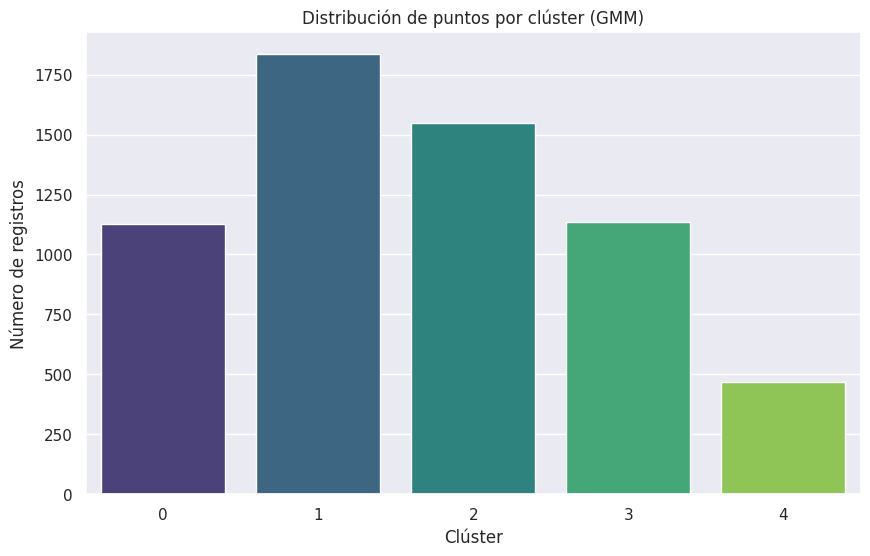

In [47]:
df_gmm = X.copy()
df_gmm['Cluster'] = gmm_labels

cluster_distrib = df_gmm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_distrib.index, y=cluster_distrib.values, palette="viridis")
plt.title('Distribución de puntos por clúster (GMM)')
plt.xlabel('Clúster')
plt.ylabel('Número de registros')
plt.show()